# Feature removal 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

from attention_lapse_detection.training.selection import select
from attention_lapse_detection.utils.paths import PATHS
from attention_lapse_detection.training.report import mean_sd

## Table 6.3 Feature-removal

In [18]:
all_runs = pd.read_csv(PATHS.root / "experiments/results/thesis_runs.csv")
MODEL, FPS, WINDOW = select(all_runs)

ablation_runs = all_runs[all_runs.features != "all_features"]


is_retained = (
    (all_runs.model == MODEL)
    & (all_runs.fps == FPS)
    & (all_runs.window_seconds == WINDOW)
)

ap = all_runs[is_retained].pivot(index="seed", columns="features", values="val_clip_ap")

base = ap.pop("all_features")
ap.columns = ap.columns.str.removeprefix("drop_")

diffs = ap.sub(base, axis=0)

ablation = pd.DataFrame(
    {
        "ap_mean": ap.mean(),
        "ap_sd": ap.std(),
        "change_mean": diffs.mean(),
        "change_sd": diffs.std(),
        "worse_of_8": (diffs < 0).sum(),
        "p": [wilcoxon(diffs[c])[1] for c in diffs],
    }
).sort_values("change_mean")

ablation["p_holm"] = multipletests(ablation.p, alpha=0.05, method="holm")[1]

print(
    f"Feature-removal model: {MODEL} {FPS}fps / {WINDOW}s; baseline AP {mean_sd(*base.agg(['mean', 'std']))} ({len(base)} seeds)"
)

table_63 = pd.DataFrame(
    {
        "Feature removed": [c for c in ablation.index],
        "AP after removal": [
            mean_sd(m, s) for m, s in zip(ablation.ap_mean, ablation.ap_sd)
        ],
        "AP change vs all features": [
            mean_sd(m, s, signed=True)
            for m, s in zip(ablation.change_mean, ablation.change_sd)
        ],
        "Runs with lower AP": [f"{n} of {len(diffs)}" for n in ablation.worse_of_8],
    }
)

table_63 

Feature-removal model: gru_uni_attention 10fps / 10s; baseline AP 0.2761 ± 0.0157 (8 seeds)


,Feature removed,AP after removal,AP change vs all features,Runs with lower AP
0,gaze_x,0.2292 ± 0.0174,-0.0468 ± 0.0199,8 of 8
1,face_present,0.2382 ± 0.0457,-0.0379 ± 0.0441,7 of 8
2,ear,0.2411 ± 0.0337,-0.0350 ± 0.0258,8 of 8
3,gaze_y,0.2419 ± 0.0432,-0.0342 ± 0.0354,8 of 8
4,blinks,0.2509 ± 0.0419,-0.0252 ± 0.0395,6 of 8
5,pitch,0.2616 ± 0.0320,-0.0145 ± 0.0250,5 of 8
6,mar,0.2671 ± 0.0293,-0.0090 ± 0.0186,4 of 8
7,roll,0.2726 ± 0.0160,-0.0034 ± 0.0137,5 of 8
8,yaw,0.2818 ± 0.0230,+0.0057 ± 0.0322,2 of 8
9,perclos,0.2861 ± 0.0166,+0.0100 ± 0.0205,2 of 8


## Figure 6.3 Paired feature-removal effects

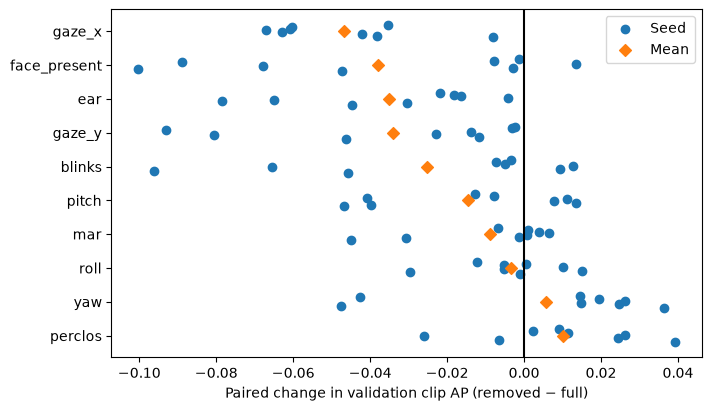

In [17]:
rows = np.arange(len(ablation))

jitter = np.linspace(-0.18, 0.18, len(diffs))

seed_x = []
seed_y = []
for row, feature in enumerate(ablation.index):
    seed_x.extend(diffs[feature])
    seed_y.extend(row + jitter)

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")

ax.scatter(seed_x, seed_y, label="Seed")
ax.scatter(ablation.change_mean, rows, marker="D", label="Mean")

ax.axvline(0, color="k")
ax.set_yticks(rows, ablation.index)

ax.invert_yaxis()
ax.set(xlabel="Paired change in validation clip AP (removed − full)")
ax.legend()

plt.show()

## Appendix: complete exploratory feature removal statistics

All ten two-sided seed-paired Wilcoxon tests are retained; Holm adjustment treats them as one comparison family.
The full table preserves raw and adjusted p-values alongside the descriptive main columns. No removal passes the
0.05 Holm threshold. 

In [24]:
print(f"Minimum Holm-adjusted p: {ablation.p_holm.min():.4f}")

table_63["Raw p"] = [f"{x:.4f}" for x in ablation.p]
table_63["Holm p"] = [f"{x:.4f}" for x in ablation.p_holm]

table_63 

Minimum Holm-adjusted p: 0.0781


,Feature removed,AP after removal,AP change vs all features,Runs with lower AP,Raw p,Holm p
0,gaze_x,0.2292 ± 0.0174,-0.0468 ± 0.0199,8 of 8,0.0078,0.0781
1,face_present,0.2382 ± 0.0457,-0.0379 ± 0.0441,7 of 8,0.0547,0.3828
2,ear,0.2411 ± 0.0337,-0.0350 ± 0.0258,8 of 8,0.0078,0.0781
3,gaze_y,0.2419 ± 0.0432,-0.0342 ± 0.0354,8 of 8,0.0078,0.0781
4,blinks,0.2509 ± 0.0419,-0.0252 ± 0.0395,6 of 8,0.2500,1.0000
5,pitch,0.2616 ± 0.0320,-0.0145 ± 0.0250,5 of 8,0.3125,1.0000
6,mar,0.2671 ± 0.0293,-0.0090 ± 0.0186,4 of 8,0.4609,1.0000
7,roll,0.2726 ± 0.0160,-0.0034 ± 0.0137,5 of 8,0.5469,1.0000
8,yaw,0.2818 ± 0.0230,+0.0057 ± 0.0322,2 of 8,0.7422,1.0000
9,perclos,0.2861 ± 0.0166,+0.0100 ± 0.0205,2 of 8,0.1953,1.0000
